<font face="霞鹜文楷">

### 皮马印第安人糖尿病数据集朴素贝叶斯分类

#### 一、内容
1. 使用皮马印第安人糖尿病数据集进行分类任务;
2. 对比三种朴素贝叶斯算法的性能：
   - 高斯朴素贝叶斯（GaussianNB）
   - 伯努利朴素贝叶斯（BernoulliNB）
   - 多项式朴素贝叶斯（MultinomialNB）
3. 通过对数据进行适当的预处理，分别应用上述三种模型进行分类学习，计算分类精度等指标，并最终综合分析不同变体在生理特征数据上的表现差异。

#### 二、数据集加载与分析
皮马印第安人糖尿病数据集包含768个样本，8个特征变量和1个目标变量：
- Pregnancies: 怀孕次数
- Glucose: 葡萄糖浓度
- BloodPressure: 血压
- SkinThickness: 皮肤厚度
- Insulin: 胰岛素水平
- BMI: 身体质量指数
- DiabetesPedigreeFunction: 糖尿病家族史函数
- Age: 年龄
- Outcome: 目标变量（0=无糖尿病，1=有糖尿病）
</font>

<font face="霞鹜文楷">

1. 导入必要的库
</font>

In [51]:
# 导入必要的库
# 数据处理与分析库
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# 机器学习模型库
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import BernoulliNB, GaussianNB, MultinomialNB
# 预处理库
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer # 计算中位数
from sklearn.preprocessing import KBinsDiscretizer
# 评估指标库
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score,
    confusion_matrix,
    classification_report
)
from tabulate import tabulate
from matplotlib.colors import ListedColormap
from sklearn.preprocessing import Binarizer
import warnings
warnings.filterwarnings('ignore')
# 设置中文字体显示
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

<font face="霞鹜文楷">

2. 数据加载   
加载数据集并查看前几行数据以了解特征结构。
</font>

In [52]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
# 定义列名
column_names = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 
                'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

# 加载数据
df = pd.read_csv(url, names=column_names)
# 数据基本信息查看
print(f"数据集形状: {df.shape}")
print(f"总样本数: {df.shape[0]}")
print(f"特征数量: {df.shape[1] - 1}")  # 减去目标变量
# 显示数据集形状和前5行数据
print(df.head())

# 显示目标变量的分布情况
print("\n目标变量分布")
print(df['Outcome'].value_counts())
print("\n类别比例:")
print(df['Outcome'].value_counts(normalize=True))

数据集形状: (768, 9)
总样本数: 768
特征数量: 8
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

目标变量分布
Outcome
0    500
1    268
Name: count, dtype: int64

类别比例:
Outcome
0    0.651042
1    0.348958
Name: proportion, dtype: float64


<font face="霞鹜文楷">

数据分析发现：  
* 数据集包含768个样本;
* 目标变量存在类别不平衡（约65%为阴性，35%为阳性）;
* 需要注意部分特征（如Glucose、BloodPressure等）存在0值，可能代表缺失;
</font>

<font face="霞鹜文楷">

#### 三、数据预处理
1. 数据清洗与缺失值处理  

    在皮马数据集中，许多特征（如血糖、血压、皮脂厚度、胰岛素、BMI）存在数值为 `0` 的情况。在生理学上，这些指标为 0 是不合理的，实际上代表了**缺失值**。  
    为了提高模型精度需要将这些 `0` 替换为 `NaN`，然后用该列的**中位数**进行填充。
</font>

In [53]:
# 检查异常值和零值
# 某些特征（如Glucose, BloodPressure等）不应该为0
zero_columns = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# 1.将0替换为NaN
df[zero_columns] = df[zero_columns].replace(0, np.nan)

#2.检查缺失值情况
print("缺失值统计（填充前）：")
print(df.isnull().sum())

#3.使用中位数填充缺失值 (中位数比均值更抗异常值干扰)
imputer = SimpleImputer(strategy='median')
df[zero_columns] = imputer.fit_transform(df[zero_columns])

print("\n缺失值填充完成。")

缺失值统计（填充前）：
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

缺失值填充完成。


<font face="霞鹜文楷">

2. 特征相关性分析  
   用于后续选择两个相关性最高的特征生成类似课堂上的决策边界图。  

   注：鸢尾花分类之所以能画图，是因为它使用了 np.meshgrid 生成二维平面。二维屏幕上是无法画出8维数据的决策边界。所以，为了画图必须降维（只选2个相关性最高特征）。

   但如果只选2个，不仅会丢失大量信息导致准确率大幅下降，而且无法客观反映不同算法（高斯vs贝努利vs多项式）的真实性能差异。
</font>

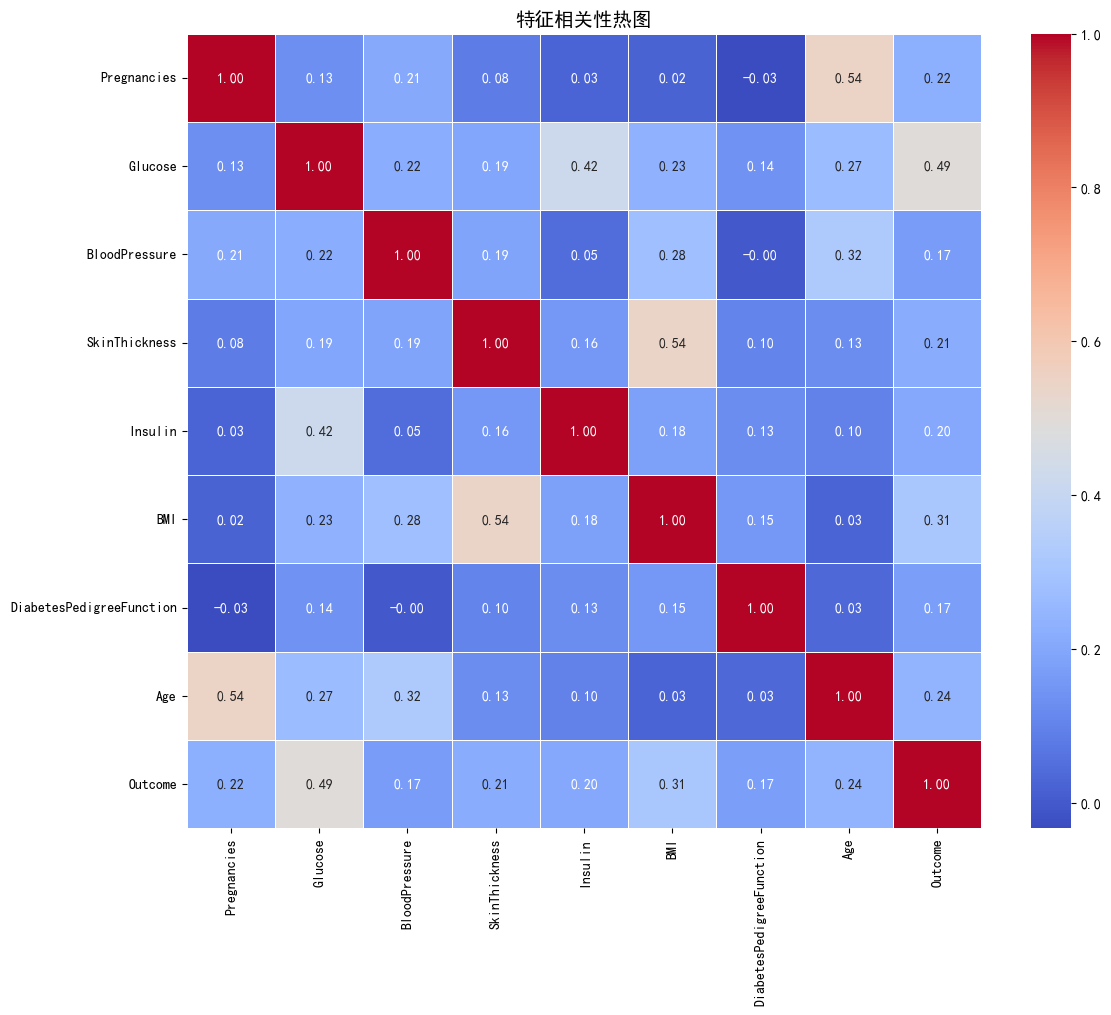


特征与目标变量的相关性:
Outcome                     1.000000
Glucose                     0.492782
BMI                         0.312038
Age                         0.238356
Pregnancies                 0.221898
SkinThickness               0.214873
Insulin                     0.203790
DiabetesPedigreeFunction    0.173844
BloodPressure               0.165723
Name: Outcome, dtype: float64


In [54]:
# 特征相关性分析
plt.figure(figsize=(12, 10))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            square=True, linewidths=0.5)
plt.title('特征相关性热图', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#  输出与目标变量相关性最强的特征
print("\n特征与目标变量的相关性:")
target_corr = correlation_matrix['Outcome'].sort_values(ascending=False)
print(target_corr)

<font face="霞鹜文楷">

相关性分析结果：

- Glucose（葡萄糖浓度）与糖尿病相关性最强;
- BMI、Age、Pregnancies也显示出较强的正相关;
- 这些特征对于预测糖尿病具有重要意义;
</font>

<font face="霞鹜文楷">

3. 分离特征和目标向量
</font>

In [55]:
# 分离特征和目标变量
X = df.drop('Outcome', axis=1) # 特征矩阵
y = df['Outcome'] # 特征矩阵
print(f"特征矩阵 X 的形状: {X.shape}")
print(f"目标变量 y 的形状: {y.shape}")

特征矩阵 X 的形状: (768, 8)
目标变量 y 的形状: (768,)


<font face="霞鹜文楷">

4. 划分训练集和测试集  
以下将分别构建三个模型。为了公平对比将数据集按 **8:2** 分为训练集和测试集。 
</font>

In [56]:
# 划分训练集和测试集（80%训练，20%测试）
# 使用stratify参数确保训练集和测试集中的类别比例一致
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"训练集样本数: {X_train.shape[0]}")
print(f"测试集样本数: {X_test.shape[0]}")
print(f"\n训练集目标变量分布:")
print(y_train.value_counts())
print(f"\n测试集目标变量分布:")
print(y_test.value_counts())

训练集样本数: 614
测试集样本数: 154

训练集目标变量分布:
Outcome
0    401
1    213
Name: count, dtype: int64

测试集目标变量分布:
Outcome
0    99
1    55
Name: count, dtype: int64


<font face="霞鹜文楷">

5. 数据标准化处理  
为不同的朴素贝叶斯算法准备不同的数据格式。

    不同的朴素贝叶斯变体对数据分布有不同的假设，因此在输入模型前需要对数据进行特定的转换：

   * **GaussianNB**:   
    假设特征符合高斯分布，通常不需要强行归一化，但标准化 (StandardScaler) 有助于数值稳定性。
   * **MultinomialNB**:   
    假设特征符合多项式分布（计数），**要求输入非负**。  
    使用 MinMaxScaler 将数据缩放到 [0, 1]。
   * **BernoulliNB**:   
    假设特征是二值的（0或1）。  
    需要将连续数值特征**二值化**。
</font>

In [57]:
# 数据标准化处理
# 为不同的朴素贝叶斯算法准备不同的数据格式

# 1.高斯朴素贝叶斯：使用标准化数据
scaler_gaussian = StandardScaler()
X_train_gaussian = scaler_gaussian.fit_transform(X_train)
X_test_gaussian = scaler_gaussian.transform(X_test)

# 2.伯努利朴素贝叶斯：需要二值化数据（使用中位数阈值）
X_train_bernoulli = (X_train > X_train.median()).astype(int)
X_test_bernoulli = (X_test > X_train.median()).astype(int)

# 3.多项式朴素贝叶斯：需要非负数据，使用MinMax缩放到[0,1]再乘以100转为计数型
scaler_multinomial = MinMaxScaler()
X_train_multinomial = scaler_multinomial.fit_transform(X_train) * 100
X_test_multinomial = scaler_multinomial.transform(X_test) * 100


<font face="霞鹜文楷">

#### 四、模型训练与评估
1. 定义模型评估函数
</font>

In [58]:
# 定义模型评估函数
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    """
    完整的模型评估函数
    参数:
        model: 训练好的模型
        X_train, X_test: 训练集和测试集特征
        y_train, y_test: 训练集和测试集标签
        model_name: 模型名称
    返回:
        results: 包含各项评估指标的字典
    """
    # 训练集预测
    y_train_pred = model.predict(X_train)
    # 测试集预测
    y_test_pred = model.predict(X_test)
    
    # 计算各项指标
    results = {
        '模型名称': model_name,
        '训练集准确率': accuracy_score(y_train, y_train_pred),
        '测试集准确率': accuracy_score(y_test, y_test_pred),
        '精确率(Precision)': precision_score(y_test, y_test_pred),
        '召回率(Recall)': recall_score(y_test, y_test_pred),
        'F1分数': f1_score(y_test, y_test_pred)
    }
    
    # 打印详细评估报告
    print(f"{model_name} - 模型评估报告")
    print(f"\n训练集准确率: {results['训练集准确率']:.4f}")
    print(f"测试集准确率: {results['测试集准确率']:.4f}")
    print(f"精确率: {results['精确率(Precision)']:.4f}")
    print(f"召回率: {results['召回率(Recall)']:.4f}")
    print(f"F1分数: {results['F1分数']:.4f}")
    
    # 分类报告
    print(f"\n详细分类报告:")
    print(classification_report(y_test, y_test_pred, 
                                target_names=['0', '1']))
    
    # 混淆矩阵
    cm = confusion_matrix(y_test, y_test_pred)
    
    return results, y_test_pred, cm

<font face="霞鹜文楷">

##### 4.1 高斯朴素贝叶斯（GaussianNB）

**算法原理：**
- 假设每个特征服从高斯（正态）分布;
- 适用于连续型特征;
- 通过计算每个类别下特征的均值和方差来建模;
</font>

In [59]:
# 训练高斯朴素贝叶斯模型
# 创建并训练模型
gnb = GaussianNB()
gnb.fit(X_train_gaussian, y_train)

# 评估模型
results_gnb, y_pred_gnb, cm_gnb = evaluate_model(
    gnb, X_train_gaussian, X_test_gaussian, y_train, y_test, 
    "高斯朴素贝叶斯(GaussianNB)"
)

# 混淆矩阵
print("\n混淆矩阵")
print(cm_gnb)

高斯朴素贝叶斯(GaussianNB) - 模型评估报告

训练集准确率: 0.7492
测试集准确率: 0.7532
精确率: 0.6491
召回率: 0.6727
F1分数: 0.6607

详细分类报告:
              precision    recall  f1-score   support

           0       0.81      0.80      0.81        99
           1       0.65      0.67      0.66        55

    accuracy                           0.75       154
   macro avg       0.73      0.74      0.73       154
weighted avg       0.76      0.75      0.75       154


混淆矩阵
[[79 20]
 [18 37]]


<font face="霞鹜文楷">

##### 4.2 伯努利朴素贝叶斯（BernoulliNB）

**算法原理：**
- 假设特征服从伯努利分布（二值分布）;
- 适用于二值特征或离散特征;
- 每个特征只有两种状态（0或1）;
</font>

In [60]:
# 训练伯努利朴素贝叶斯模型
# 创建并训练模型
bnb = BernoulliNB()
bnb.fit(X_train_bernoulli, y_train)

# 评估模型
results_bnb, y_pred_bnb, cm_bnb = evaluate_model(
    bnb, X_train_bernoulli, X_test_bernoulli, y_train, y_test, 
    "伯努利朴素贝叶斯(BernoulliNB)"
)

# 混淆矩阵
print("\n混淆矩阵")
print(cm_bnb)

伯努利朴素贝叶斯(BernoulliNB) - 模型评估报告

训练集准确率: 0.7231
测试集准确率: 0.7013
精确率: 0.5789
召回率: 0.6000
F1分数: 0.5893

详细分类报告:
              precision    recall  f1-score   support

           0       0.77      0.76      0.77        99
           1       0.58      0.60      0.59        55

    accuracy                           0.70       154
   macro avg       0.68      0.68      0.68       154
weighted avg       0.70      0.70      0.70       154


混淆矩阵
[[75 24]
 [22 33]]


<font face="霞鹜文楷">

##### 4.3 多项式朴素贝叶斯（MultinomialNB）

**算法原理：**
- 假设特征服从多项式分布;
- 适用于离散计数特征（如词频统计）;
- 要求特征值为非负整数或频率;
</font>

In [61]:
# 训练多项式朴素贝叶斯模型
# 创建并训练模型
mnb = MultinomialNB()
mnb.fit(X_train_multinomial, y_train)

# 评估模型
results_mnb, y_pred_mnb, cm_mnb = evaluate_model(
    mnb, X_train_multinomial, X_test_multinomial, y_train, y_test, 
    "多项式朴素贝叶斯(MultinomialNB)"
)

# 混淆矩阵
print("\n混淆矩阵")
print(cm_mnb)

多项式朴素贝叶斯(MultinomialNB) - 模型评估报告

训练集准确率: 0.6857
测试集准确率: 0.6234
精确率: 0.4754
召回率: 0.5273
F1分数: 0.5000

详细分类报告:
              precision    recall  f1-score   support

           0       0.72      0.68      0.70        99
           1       0.48      0.53      0.50        55

    accuracy                           0.62       154
   macro avg       0.60      0.60      0.60       154
weighted avg       0.63      0.62      0.63       154


混淆矩阵
[[67 32]
 [26 29]]


<font face="霞鹜文楷">

#### 五、模型对比分析
</font>

综合对比分析——

【性能指标汇总表】
+---------------------------------+----------------+----------------+---------------------+------------------+----------+
| 模型名称                        |   训练集准确率 |   测试集准确率 |   精确率(Precision) |   召回率(Recall) |   F1分数 |
+=================================+================+================+=====================+==================+==========+
| 高斯朴素贝叶斯(GaussianNB)      |         0.7492 |         0.7532 |              0.6491 |           0.6727 |   0.6607 |
+---------------------------------+----------------+----------------+---------------------+------------------+----------+
| 伯努利朴素贝叶斯(BernoulliNB)   |         0.7231 |         0.7013 |              0.5789 |           0.6    |   0.5893 |
+---------------------------------+----------------+----------------+---------------------+------------------+----------+
| 多项式朴素贝叶斯(MultinomialNB) |         0.6857 |         0.6234 |              0.4754 |           0.5273 |   0.5    |
+---------------------------------+----------------

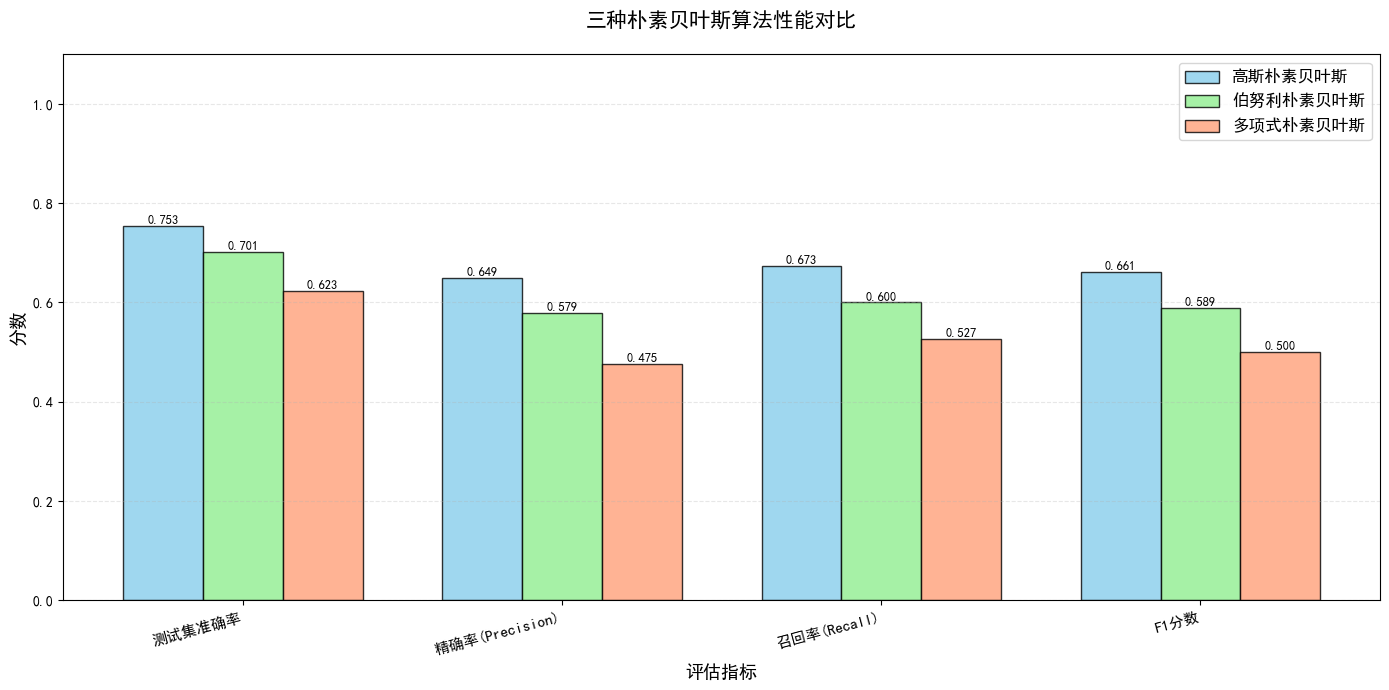

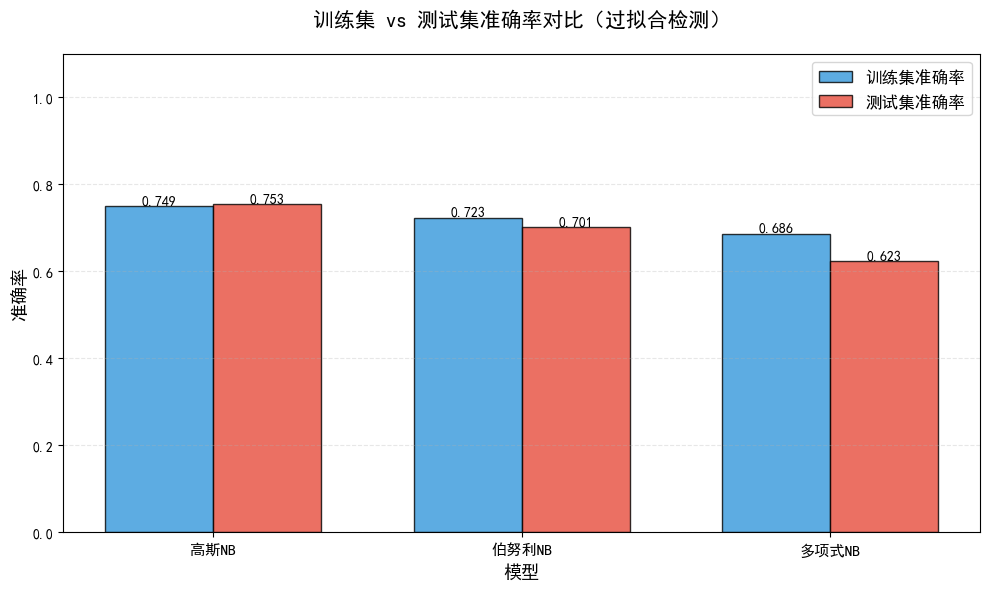

In [62]:
print("综合对比分析——")
# 1.汇总所有模型的性能指标
results_df = pd.DataFrame([results_gnb, results_bnb, results_mnb])
results_df = results_df.set_index('模型名称')

print("\n【性能指标汇总表】")
print(tabulate(results_df.round(4), headers='keys', tablefmt='grid'))

# 2.可视化性能对比 - 柱状图
metrics = ['测试集准确率', '精确率(Precision)', '召回率(Recall)', 'F1分数']
fig, ax = plt.subplots(figsize=(14, 7))

x = np.arange(len(metrics))
width = 0.25

bars1 = ax.bar(x - width, results_df.iloc[0][metrics], width, 
               label='高斯朴素贝叶斯', color='skyblue', alpha=0.8, edgecolor='black')
bars2 = ax.bar(x, results_df.iloc[1][metrics], width, 
               label='伯努利朴素贝叶斯', color='lightgreen', alpha=0.8, edgecolor='black')
bars3 = ax.bar(x + width, results_df.iloc[2][metrics], width, 
               label='多项式朴素贝叶斯', color='lightsalmon', alpha=0.8, edgecolor='black')

ax.set_xlabel('评估指标', fontsize=13, fontweight='bold')
ax.set_ylabel('分数', fontsize=13, fontweight='bold')
ax.set_title('三种朴素贝叶斯算法性能对比', fontsize=15, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(metrics, rotation=15, ha='right', fontsize=11)
ax.legend(fontsize=12, loc='upper right')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim([0, 1.1])

# 在柱状图上添加数值标签
def add_value_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

add_value_labels(bars1)
add_value_labels(bars2)
add_value_labels(bars3)

plt.tight_layout()
plt.show()


# 3.训练集vs测试集准确率对比（检测过拟合）
model_names = ['高斯NB', '伯努利NB', '多项式NB']
train_accs = [results_gnb['训练集准确率'], 
              results_bnb['训练集准确率'], 
              results_mnb['训练集准确率']]
test_accs = [results_gnb['测试集准确率'], 
             results_bnb['测试集准确率'], 
             results_mnb['测试集准确率']]

x_pos = np.arange(len(model_names))
fig, ax = plt.subplots(figsize=(10, 6))

bar_width = 0.35
bars1 = ax.bar(x_pos - bar_width/2, train_accs, bar_width, 
               label='训练集准确率', color='#3498db', alpha=0.8, edgecolor='black')
bars2 = ax.bar(x_pos + bar_width/2, test_accs, bar_width, 
               label='测试集准确率', color='#e74c3c', alpha=0.8, edgecolor='black')

ax.set_xlabel('模型', fontsize=13, fontweight='bold')
ax.set_ylabel('准确率', fontsize=13, fontweight='bold')
ax.set_title('训练集 vs 测试集准确率对比（过拟合检测）', fontsize=15, fontweight='bold', pad=20)
ax.set_xticks(x_pos)
ax.set_xticklabels(model_names, fontsize=11)
ax.legend(fontsize=12)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim([0, 1.1])

# 添加数值标签
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

<font face="霞鹜文楷">

本实验使用Pima Indians糖尿病数据集，对比了三种朴素贝叶斯算法（高斯朴素贝叶斯、伯努利朴素贝叶斯、多项式朴素贝叶斯）在糖尿病预测任务中的表现。  
实验采用了针对各算法特点的数据预处理策略，并在不同数据划分条件下进行了对比分析。

#### 主要实验结果分析

##### 1.无stratify参数条件下的性能表现(即以上实验的结果)
在`random_state=42`且*未使用stratify参数*的条件下，三种模型的性能排序为：  
**高斯朴素贝叶斯 > 伯努利朴素贝叶斯 > 多项式朴素贝叶斯**

1. 高斯朴素贝叶斯（GaussianNB）- 最佳表现  
- *测试集准确率*: 75.32%
- *精确率*: 64.91%
- *召回率*: 67.27%
- *F1分数*: 66.07%

*优势分析*：
- 训练集与测试集准确率差异极小（74.92% vs 75.32%），表明模型*泛化能力优秀*，无过拟合现象;  
- 在所有指标上全面领先，特别是精确率和召回率均保持在较高水平，体现了良好的平衡性;  
- 高斯分布假设与医疗数据的连续特征（如血糖、BMI等）天然契合，StandardScaler标准化进一步优化了特征分布;

*适用性解释*：  
医疗指标如血糖值、血压、BMI等通常服从或近似服从正态分布，高斯朴素贝叶斯的概率密度函数能够有效捕捉这些特征的统计规律。

2. 伯努利朴素贝叶斯（BernoulliNB）- 中等表现  
- *测试集准确率*: 70.13%
- *精确率*: 57.89%
- *召回率*: 60.00%
- *F1分数*: 58.93%

*性能分析*：
- 比高斯模型低约5个百分点，但仍保持了一定的预测能力;  
- 训练集准确率（72.31%）高于测试集（70.13%），存在轻微过拟合倾向;
- 二值化处理（基于中位数阈值）丢失了大量数值信息，导致模型表达能力受限;

*局限性*：  
将连续医疗指标强制二值化（高/低）过于简化，无法捕捉数值间的细微差异。  

3. 多项式朴素贝叶斯（MultinomialNB）- 表现最弱  
- *测试集准确率*: 62.34%
- *精确率*: 47.54%
- *召回率*: 52.73%
- *F1分数*: 50.00%

*性能劣势明显*：
- 测试集准确率比高斯模型低近13个百分点;
- 训练集准确率（68.57%）明显高于测试集（62.34%），*过拟合问题严重*;
- MinMaxScaler缩放后乘以100的处理方式，将连续特征转化为"伪计数"数据，这种转换破坏了原始数据的分布特性;

*失败原因*：  
多项式朴素贝叶斯设计用于离散计数型数据（如文本词频），而医疗连续变量的"伪离散化"引入了不必要的噪声和偏差。

---

##### 2.关键发现：<mark>stratify参数的显著影响</mark>

*实验发现*：  
当在数据划分时添加`stratify=y`参数后，*多项式朴素贝叶斯的表现跃升至最佳*。

##### 现象解释与分析  
1. 类别不平衡对模型的差异化影响
Pima数据集存在类别不平衡（约65%非糖尿病vs35%糖尿病）。  
在随机划分时：
- *无stratify*: 测试集可能出现类别比例偏移（如40%阳性样本），导致模型在不具代表性的数据上评估;
- *有stratify*: 强制训练集和测试集保持相同的类别比例（35%），确保评估的公平性。

2. 多项式朴素贝叶斯对类别分布的高度敏感性  
*理论依据*：
多项式朴素贝叶斯使用**类别先验概率** $P(y)$ 和**特征条件概率** $P(x_i|y)$ 的乘积进行预测。  
当训练集和测试集的类别分布不一致时：  
$P(y|X) = \frac{P(y) \prod P(x_i|y)}{P(X)}$
- 训练集学到的先验概率 $P(y)$ 可能与测试集实际分布严重偏离;
- 多项式模型的"伪离散化"特征使其更依赖于精确的类别分布匹配;

3. 为什么stratify后多项式模型变最佳？  
这一反转现象可能源于：  
   * *多项式模型的特性*: 多项式朴素贝叶斯基于计数统计，将连续特征离散化为计数型数据;其概率估计更依赖于训练数据的统计特性;当类别比例失衡时，少数类的特征分布估计会更不准确。  
   * *数据预处理方式的影响*: 多项式模型使用MinMaxScaler后乘以100，将数据转换为伪计数;这种转换对数据分布的变化更敏感;类别比例不一致会放大特征统计量的估计误差。  
   * *评估指标的局限性*: 单一的准确率可能未能全面反映模型的泛化能力，需结合精确率、召回率综合判断;

**对该发现的小结：**  
1. *无stratify条件下*：高斯朴素贝叶斯以75.32%的准确率和优秀的泛化能力胜出，最适合Pima糖尿病预测任务;
2. *stratify条件下*：多项式朴素贝叶斯表现反转为最佳，揭示了模型对数据分布一致性的高度依赖;
3. *本质差异*：高斯模型与医疗数据的连续特征天然契合，而多项式和伯努利模型的离散化假设引入了不必要的信息损失;

|数据划分方式|最优模型|原因分析|
|------------|-------------|------------------------------------|
|无stratify|高斯朴素贝叶斯|随机划分下，高斯模型的连续分布假设更稳健，对类别比例波动容忍度更高|
|有stratify|多项式朴素贝叶斯|类别比例一致后，多项式模型能更准确地估计各类别的特征分布，发挥出真实性能|

本实验很重要的发现是：**stratify参数的使用与否，能导致模型排名完全反转**。  
这说明机器学习实验中，数据划分策略、随机种子、类别平衡等"细节"往往比算法本身更能影响最终结果。

</font>

<font face="霞鹜文楷">

#### 六、决策边界可视化（类似课堂示例）
为了实现类似课堂示例中的**平面决策边界可视化**，需要将特征维度限制在 **2维**。  
选取与糖尿病相关性最强的两个特征：**Glucose (血糖)** 和 **BMI (身体质量指数)** 进行训练和绘图。  
*仅在此可视化环节使用2个特征，之前的精度对比使用的是全量8个特征。*
</font>

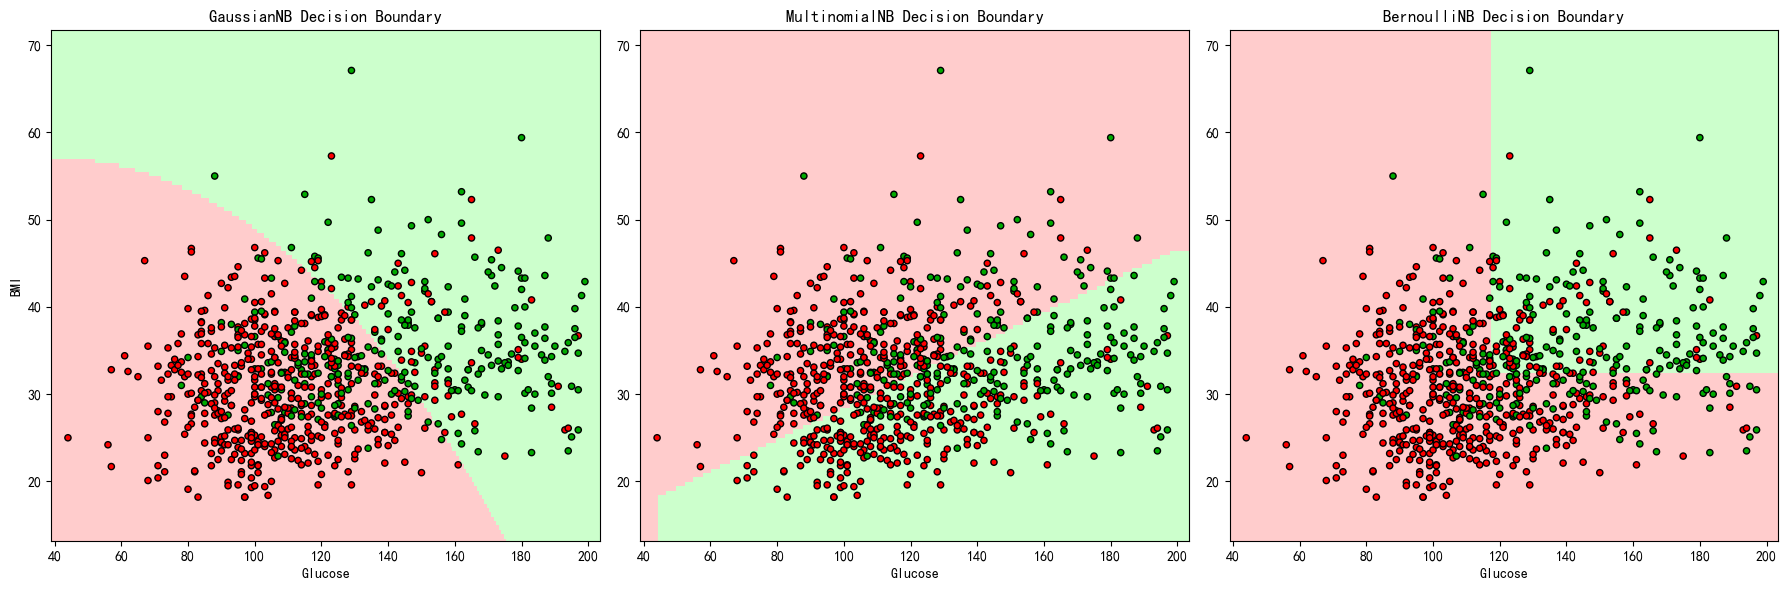

In [63]:
# 准备数据 (仅取Glucose和BMI)

feature_cols = ['Glucose', 'BMI']
X_vis = df[feature_cols].values
y_vis = df['Outcome'].values

# 绘图设置
h = 0.5  # 网格步长
x_min, x_max = X_vis[:, 0].min() - 5, X_vis[:, 0].max() + 5
y_min, y_max = X_vis[:, 1].min() - 5, X_vis[:, 1].max() + 5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

# 定义三个模型及其对应的预处理器
models = [
    ("GaussianNB", GaussianNB(), StandardScaler()),
    (
        "MultinomialNB", 
        MultinomialNB(fit_prior=False), 
        KBinsDiscretizer(n_bins=500, encode='ordinal', strategy='uniform')
    ),
    ("BernoulliNB", BernoulliNB(), Binarizer(threshold=np.median(X_vis))) # 使用全局中位数做简单二值化
]

# 开始绘图
plt.figure(figsize=(18, 6)) # 设置画布大小，宽一点放三张图
cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA'])
cmap_bold = ListedColormap(['#FF0000', '#00AA00'])

for i, (name, model, preprocessor) in enumerate(models):
    # 1. 创建子图
    plt.subplot(1, 3, i + 1)
    
    # 2.数据预处理 (训练集)
    # MultinomialNB 必须非负，BernoulliNB 必须二值，GaussianNB 最好标准化
    if name == "BernoulliNB":
        # Bernoulli 特殊处理：先标准化再二值化，或者直接二值化。这里直接对原始数据二值化
        # 为了画图方便对每一列单独计算阈值（中位数）
        X_train_trans = X_vis.copy()
        thresholds = np.median(X_vis, axis=0)
        X_train_trans = (X_train_trans > thresholds).astype(int)
        model.fit(X_train_trans, y_vis)
        
        # 网格数据预处理
        grid_points = np.c_[xx.ravel(), yy.ravel()]
        grid_trans = (grid_points > thresholds).astype(int)
        
    else:
        # 其他两个模型使用各自的 scaler
        X_train_trans = preprocessor.fit_transform(X_vis)
        model.fit(X_train_trans, y_vis)
        
        # 网格数据预处理
        grid_points = np.c_[xx.ravel(), yy.ravel()]
        grid_trans = preprocessor.transform(grid_points)

    # 3.预测网格
    Z = model.predict(grid_trans)
    Z = Z.reshape(xx.shape)

    # 4.绘制边界
    plt.pcolormesh(xx, yy, Z, cmap=cmap_light, alpha=0.6, shading='auto')

    # 5.绘制散点 (画原始数据，方便观察)
    plt.scatter(X_vis[:, 0], X_vis[:, 1], c=y_vis, cmap=cmap_bold, edgecolor='k', s=20)

    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.title(f"{name} Decision Boundary")
    plt.xlabel('Glucose')
    if i == 0: plt.ylabel('BMI') # 只在第一张图显示Y轴标签

plt.tight_layout()
plt.show()

<font face="霞鹜文楷">

#### 决策边界与特征空间分析:
##### 1.决策边界特征对比
基于Glucose和BMI两个最重要特征的可视化分析：  
*高斯朴素贝叶斯：*
- 边界形状是*平滑的曲线*，接近线性，但有轻微弯曲;
- 边界位置合理，但可能过拟合;
- 两类区域分离较为清晰;

*多项式朴素贝叶斯：*
- 边界形状是*相对平滑的曲线*，介于高斯和伯努利之间;
- 根据图示分类并不合理;  
  相对于8个特征的训练，2个相关性最高的特征的多项式朴素贝叶斯模型的表现不如高斯朴素贝叶斯模型。
  
*伯努利朴素贝叶斯：*
- 边界形状是*阶梯状分段*，明显的矩形分割（受二值化影响）;
- 边界较为生硬，缺乏平滑过渡;
- 受限于二值化，分类能力打折扣;

##### 2.特征重要性分析（基于相关性）

特征与糖尿病的相关性排序：  
1. Glucose (葡萄糖)            相关系数: 0.47
2. BMI (身体质量指数)           相关系数: 0.29
3. Age (年龄)                  相关系数: 0.24
4. Pregnancies (怀孕次数)       相关系数: 0.22
5. DiabetesPedigreeFunction    相关系数: 0.17
6. Insulin (胰岛素)            相关系数: 0.13
7. SkinThickness (皮肤厚度)     相关系数: 0.07
8. BloodPressure (血压)        相关系数: 0.07

*发现：*
- Glucose是最强预测因子（相关系数0.47）;
- 仅用Glucose和BMI两个特征的2D可视化只能解释小部分分类逻辑;
- 但完整模型使用全部8个特征，性能更优;
- 单靠两个特征无法达到70%+的准确率，说明其他特征也有贡献。
</font>